一、Python的变量本质

1.1 变量是对象的引用

在Python中，变量不是存储数据的容器，而是指向对象的引用（标签）。

1.2 对象三要素

每个对象都有三个要素：
*    类型 (type)：决定了对象的属性和方法
*    值 (value)：对象存储的数据
*    标识 (id)：对象在内存中的唯一地址

In [ ]:
x = 42
print(id(x))      # 140735567267552 (内存地址)
print(type(x))    # <class 'int'>
print(x)          # 42

二、Python参数传递机制
*    Python 的参数传递是“按对象引用传递”，即传递的是对象引用的副本，不是值传递或者引用传递

In [1]:
def modify(x):
    print(f"函数内x的id: {id(x)}")
    x = 100
    print(f"重新赋值后x的id: {id(x)}")

y = 50
print(f"调用前y的id: {id(y)}")
modify(y)
print(f"调用后y的值: {y}")

调用前y的id: 140724710056400
函数内x的id: 140724710056400
重新赋值后x的id: 140724710058000
调用后y的值: 50


三、不可变对象与可变对象

   Python 中的对象分为可变（mutable）和不可变（immutable）两种。

  不可变对象：
* 数值类型（int, float, complex）、字符串（str）、元组（tuple）、布尔（bool）、frozenset
* 不可变对象一旦创建，其内容就不能改变。如果尝试改变，Python 会创建一个新的对象。
* 当传递不可变对象时，函数内部对参数的操作（如重新赋值）不会影响原始对象，因为不可变对象无法修改，任何修改
  都会创建一个新的对象。
* 简单理解就是，当不可变对象引用作为函数参数时，相当于局部参数，无法对外部参数产生影响

In [ ]:
def reassign(param):#传递的是地址值的副本
    param = "new value"  # param这个original引用的副本现在指向新对象

original = "old value"
reassign(original)
print(original)  # 输出: "old value"原始的引用依旧指向原始的对象

Python中实现"类似指针"效果的方案：（针对不可变对象）
1. 使用可变对象包装


2. 使用类成员变量
3. 使用闭包+nonlocal

        nonlocal num  # 声明num不是局部变量

4. 返回修改后的值，使引用指向一个新的对象

可变对象：
* 列表（list）、字典（dict）、集合（set）、自定义类实例（通常）
* 可变对象的内容可以改变，而对象本身（内存地址）不变。
* 当传递可变对象时，函数内部对参数的操作（如修改列表元素）会影响原始对象，因为函数内的参数和原始变量指向同一个对象。

In [5]:
#默认参数在函数定义时计算，因此避免使用可变对象作为默认值，除非有意为之。
#我们想的是每次在使用的时候创建一个新的列表，但实际上不是这样的
def bad_append(item, lst=[]):
    """错误：默认列表只创建一次！"""
    lst.append(item)
    return lst

print(bad_append(1))  # [1]
print(bad_append(2))  # [1, 2] 不是[2]！

#正确做法
def good_append(item, lst=None):
    """正确：每次调用创建新列表"""
    if lst is None:
        lst = []
    lst.append(item)
    return lst

print(good_append(1))  # [1]
print(good_append(2))  # [2]

[1]
[1, 2]
[1]
[2]


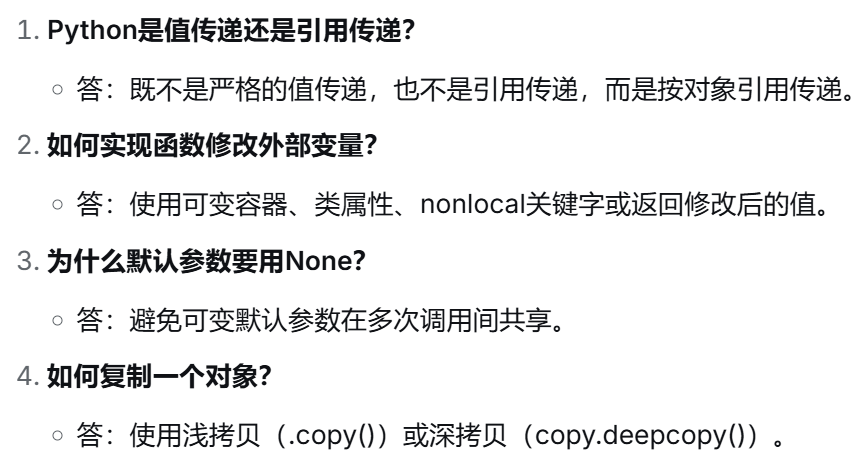

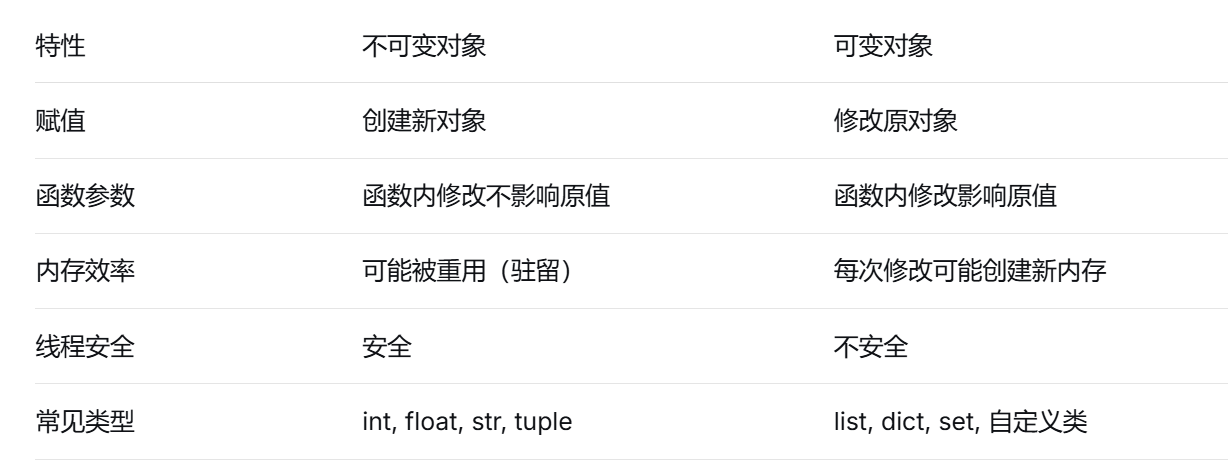

**_二.Python 中的哈希表数据结构详解_**

1. defaultdict - 默认值字典：

        defaultdict(list): 创建默认值为空列表的字典,访问或往不存在的键中添加数据时会自动创建空列表，其他同理
        defaultdict(int) - 整数0作为默认值
        defaultdict(set) - 集合作为默认值


2. Counter - 计数器

In [ ]:
from collections import Counter

# 1. 从可迭代对象创建
words = ['apple', 'banana', 'apple', 'orange', 'banana', 'apple']
word_counter = Counter(words)
print(word_counter)
# Counter({'apple': 3, 'banana': 2, 'orange': 1})

# 2. 从字符串创建
letter_counter = Counter('abracadabra')
print(letter_counter)
# Counter({'a': 5, 'b': 2, 'r': 2, 'c': 1, 'd': 1})

# 3. 常用方法
print(letter_counter.most_common(3))  # 最常见的3个元素
# [('a', 5), ('b', 2), ('r', 2)]

# 4. 更新计数器
c1 = Counter({'a': 3, 'b': 2})
c2 = Counter({'a': 1, 'c': 4})
c1.update(c2)
print(c1)  # Counter({'a': 4, 'c': 4, 'b': 2})

# 5. 加减操作
c3 = Counter({'a': 5, 'b': 3})
c4 = Counter({'a': 2, 'b': 4})
print(c3 + c4)  # Counter({'a': 7, 'b': 7})
print(c3 - c4)  # Counter({'a': 3})

3.普通字典：

In [ ]:
# 1. 创建空字典
d1 = {}
d2 = dict()

# 2. 创建有初始值的字典
d3 = {'a': 1, 'b': 2}
d4 = dict(a=1, b=2)

# 3. 访问不存在的键会报错
# print(d1['c'])  # KeyError

# 4. 使用 get() 方法避免 KeyError
print(d3.get('c', 0))  # 返回 0（默认值）

# 5. 使用 setdefault() 设置默认值
d3.setdefault('c', 0)  # 如果 'c' 不存在，设置为 0
print(d3)  # {'a': 1, 'b': 2, 'c': 0}

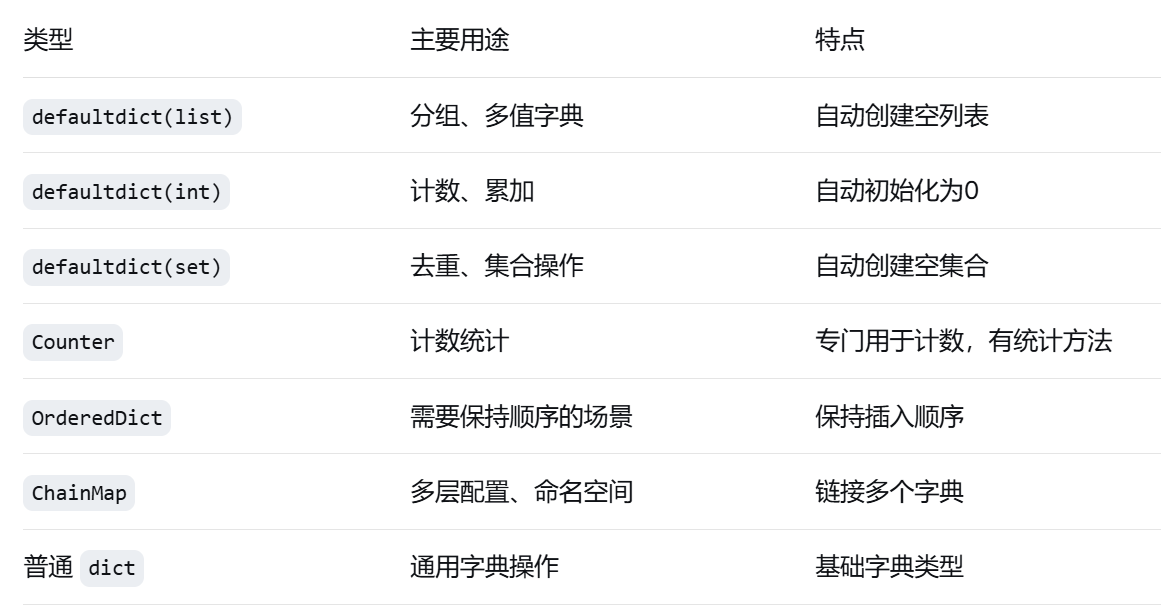

**_python包管理机制详解：_**

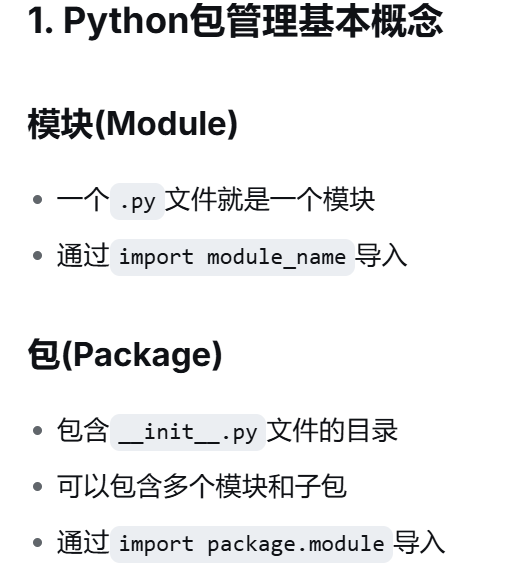

2._init_.py的作用：

    （1）标记目录为Python包：

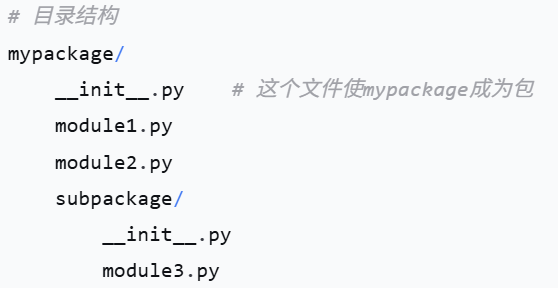

    （2）简化导入路径：

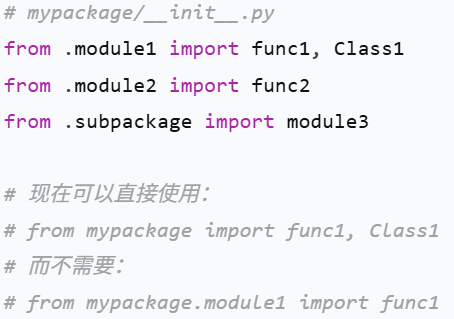

#3._all_属性的作用:

    (1)在模块中定义__all__:控制from module import *导入的内容

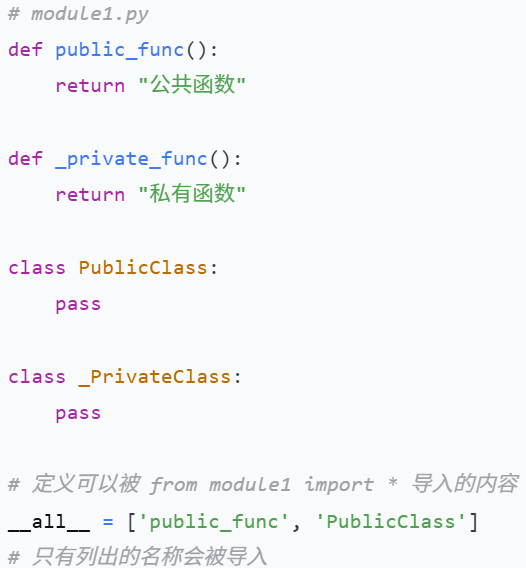

    (2)在包中定义__all__:控制from package import *导入的模块

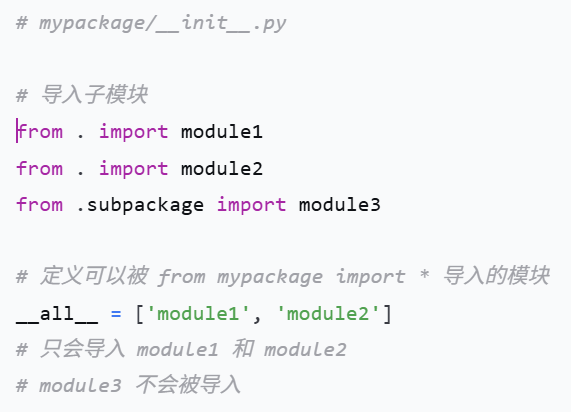

其中:

    from . import xxx 中.意味着从当前的包导入某个模块，..意味着从当前包的父包中导入某个模块，以此类推
    from .module1 import xxx 意味着从当前包的某个模块中导入内容

为你整理的 Python 核心概念笔记（简洁版）：

### 1. `**kwargs`：关键字参数打包器
* **全称**：Keyword Arguments（关键字参数）。
* **语法**：参数名前加两个星号 `**`（名称 `kwargs` 是惯例，可自定义）。
* **核心功能**：
    * 将函数调用时传入的所有 `key=value` 形式的参数，自动打包成一个 **字典 (dict)**。
    * 用于处理“不确定用户会传多少个具名参数”的情况。
* **示例**：
    ```python
    def func(**kwargs):
        print(kwargs)

    func(a=1, b=2)  # 输出：{'a': 1, 'b': 2}
    ```

### 2. `self`：实例对象的“指代词”
* **本质**：指向 **当前实例对象本身** 的引用。
* **核心作用**：
    1.  **内部通信**：在类的内部，让方法 A 可以调用属性 B 或方法 C（通过 `self.xxx`）。
    2.  **数据隔离（非常重要）**：确保不同对象之间的数据互不干扰。**你之前说的“对象之间共享”是不准确的**，它实际上是为了实现“**对象内方法间共享，对象间数据隔离**”。
    3.  **区分范围**：区分哪些是“属于这个房子的”（成员变量 `self.x`），哪些是“临时的”（局部变量 `x`）。
* **理解误区纠正**：
    * `self` 就像你的名字“我”。当张三说“我的书”时，指向的是张三的书；当李四说“我的书”时，指向的是李四的书。
    * 不同对象（张三和李四）通过 `self` 各自保存自己的信息，而不是互相共享。

* **关于 self 的状态保持**：
    * 普通函数的变量是“用完即毁”的局部变量，想要保留数据必须靠 return 传递到外部。
    * 而带有 self. 前缀的变量（实例变量），数据会随着对象一直存在（保存在对象自己的内存空间里）。对象内的不同方法可以随时读写这些数据，免去了在函数之间传来传去的麻烦。

---
### 补充记忆点：
* **kwargs** 的双星号 `**` 是解包/打包字典的魔法符号。
* **self** 不是 Python 的关键字，它是约定俗成的。你写 `this` 也可以运行，但为了代码可读性，**永远使用 `self`**。
* **`*args`** 是 `**kwargs` 的好兄弟，它只负责打包没有名字的参数（变成元组）。